<a href="https://colab.research.google.com/github/IoannisChamos/orchard-precision-farming/blob/main/notebooks/01_build_orchard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas rasterio networkx laspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [8]:
from shapely.geometry import Point, LineString, box

In [4]:
crs = "EPSG:28992"

In [9]:
field_geometry = box(
    110000,
    480000,
    110120,
    480080
)

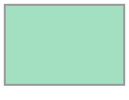

In [10]:
field_geometry

In [11]:
min_x = 110000
min_y = 480000
max_x = 110120
max_y = 480080

field_geometry = box(min_x, min_y, max_x, max_y)

In [12]:
field = gpd.GeoDataFrame(
    {
        "field_id": ["orchard_01"],
        "crop": ["apple"]
    },
    geometry=[field_geometry],
    crs=crs
)

In [13]:
field

,field_id,crop,geometry
0,orchard_01,apple,"POLYGON ((110120 480000, 110120 480080, 110000..."


In [15]:
print("Coordinate system:", field.crs)
print("Field area:", field.geometry.area.iloc[0], "m²")
print("Valid geometry:", field.geometry.is_valid.iloc[0])

Coordinate system: EPSG:28992
Field area: 9600.0 m²
Valid geometry: True


In [16]:
row_01_geometry = LineString([
    (110010, 480008),
    (110010, 480072)
])

In [17]:
row_01 = gpd.GeoDataFrame(
    {
        "row_id": ["R01"]
    },
    geometry=[row_01_geometry],
    crs=crs
)

In [18]:
print("Row length:", row_01.geometry.length.iloc[0], "m")

Row length: 64.0 m


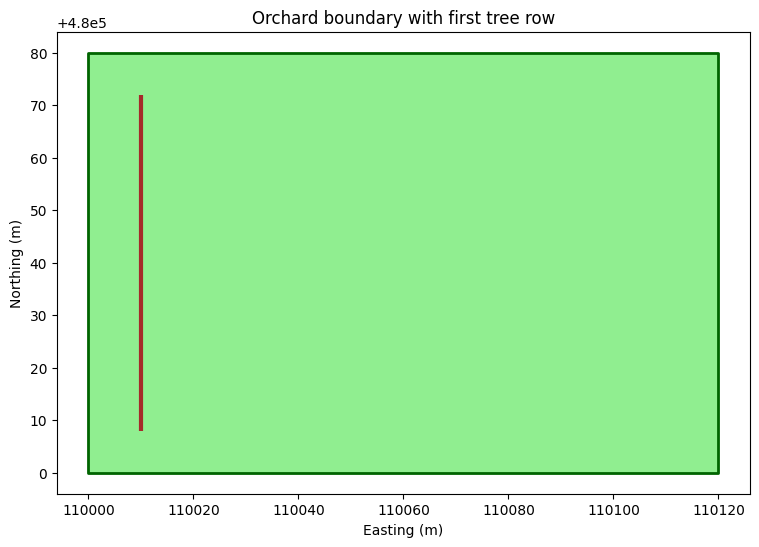

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

field.plot(
    ax=ax,
    facecolor="lightgreen",
    edgecolor="darkgreen",
    linewidth=2
)

row_01.plot(
    ax=ax,
    color="brown",
    linewidth=3
)

ax.set_title("Orchard boundary with first tree row")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.show()

In [20]:
fig.set_size_inches(12, 8)